In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [2]:
# Cell 2: Load Diabetes Dataset
diabetes_df = pd.read_csv('../data/raw/diabetes.csv')

print("=" * 50)
print("DIABETES DATASET")
print("=" * 50)
print(f"\nShape: {diabetes_df.shape}")
print(f"Rows: {diabetes_df.shape[0]}, Columns: {diabetes_df.shape[1]}")

print("\n--- Column Names ---")
print(diabetes_df.columns.tolist())

print("\n--- First 5 Rows ---")
print(diabetes_df.head())

print("\n--- Data Types ---")
print(diabetes_df.dtypes)

print("\n--- Missing Values ---")
print(diabetes_df.isnull().sum())

print("\n--- Statistical Summary ---")
print(diabetes_df.describe())

print("\n--- Target Variable Distribution ---")
if 'Outcome' in diabetes_df.columns:
    print(diabetes_df['Outcome'].value_counts())


DIABETES DATASET

Shape: (768, 9)
Rows: 768, Columns: 9

--- Column Names ---
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

--- First 5 Rows ---
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

--- Data Types ---
Pregnancies                   int64
Glucose               

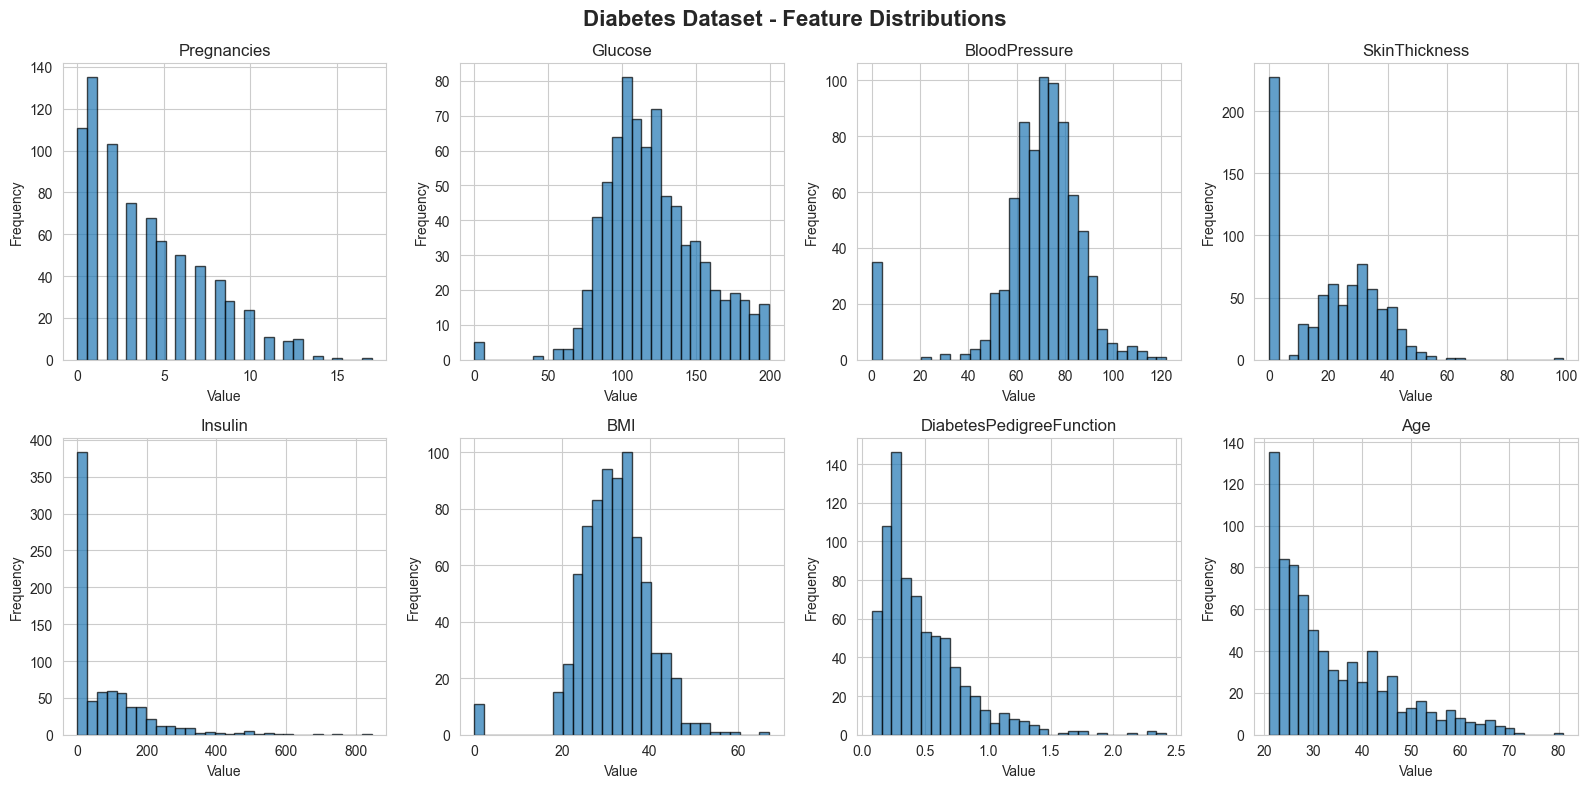

✅ Visualization saved to results/plots/diabetes_distributions.png


In [3]:
# Cell 3: Visualize Diabetes Data
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Diabetes Dataset - Feature Distributions', fontsize=16, fontweight='bold')

# Plot histograms for each feature
numeric_cols = diabetes_df.select_dtypes(include=[np.number]).columns
for idx, col in enumerate(numeric_cols[:8]):
    row = idx // 4
    col_idx = idx % 4
    axes[row, col_idx].hist(diabetes_df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].set_xlabel('Value')
    axes[row, col_idx].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../results/plots/diabetes_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved to results/plots/diabetes_distributions.png")


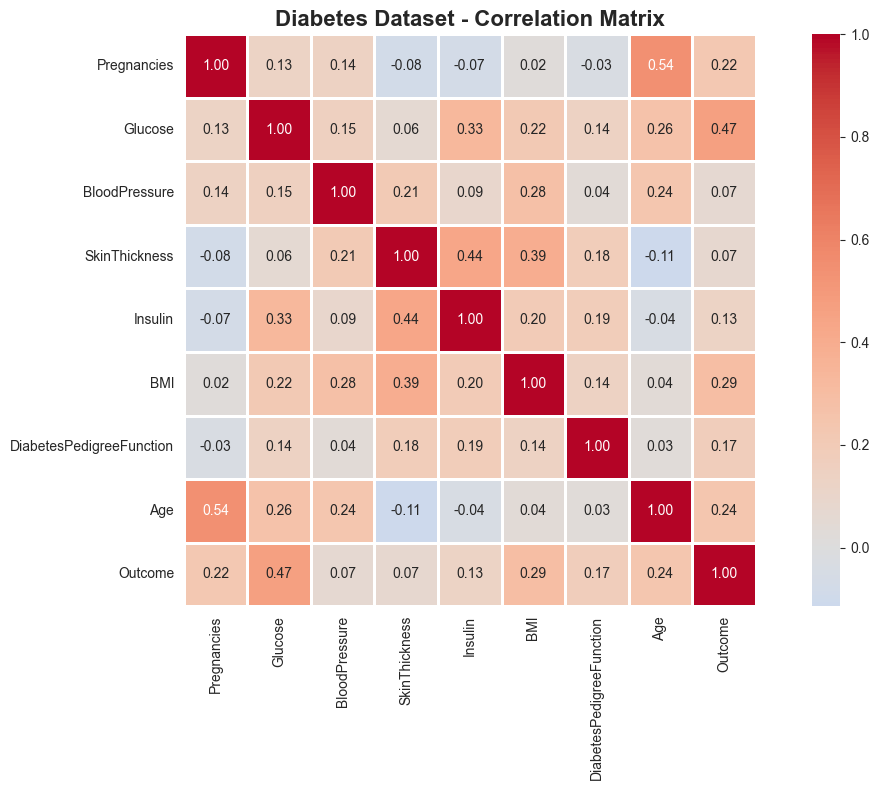

✅ Correlation matrix saved!


In [4]:
# Cell 4: Correlation Analysis
plt.figure(figsize=(12, 8))
correlation_matrix = diabetes_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Diabetes Dataset - Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/diabetes_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Correlation matrix saved!")


In [5]:
# Cell 5: Load Nutrition Dataset
try:
    nutrition_df = pd.read_csv('../data/raw/nutrition.csv')
    
    print("=" * 50)
    print("NUTRITION DATASET")
    print("=" * 50)
    print(f"\nShape: {nutrition_df.shape}")
    print(f"Rows: {nutrition_df.shape[0]}, Columns: {nutrition_df.shape[1]}")
    
    print("\n--- Column Names ---")
    print(nutrition_df.columns.tolist())
    
    print("\n--- First 5 Rows ---")
    print(nutrition_df.head())
    
    print("\n--- Data Types ---")
    print(nutrition_df.dtypes)
    
    print("\n--- Missing Values ---")
    print(nutrition_df.isnull().sum())
    
    print("\n--- Statistical Summary ---")
    print(nutrition_df.describe())
    
except FileNotFoundError:
    print("⚠️ Nutrition dataset not found. Please download from Kaggle.")


NUTRITION DATASET

Shape: (7413, 48)
Rows: 7413, Columns: 48

--- Column Names ---
['Category', 'Description', 'Nutrient Data Bank Number', 'Data.Alpha Carotene', 'Data.Ash', 'Data.Beta Carotene', 'Data.Beta Cryptoxanthin', 'Data.Carbohydrate', 'Data.Cholesterol', 'Data.Choline', 'Data.Fiber', 'Data.Kilocalories', 'Data.Lutein and Zeaxanthin', 'Data.Lycopene', 'Data.Manganese', 'Data.Niacin', 'Data.Pantothenic Acid', 'Data.Protein', 'Data.Refuse Percentage', 'Data.Retinol', 'Data.Riboflavin', 'Data.Selenium', 'Data.Sugar Total', 'Data.Thiamin', 'Data.Water', 'Data.Fat.Monosaturated Fat', 'Data.Fat.Polysaturated Fat', 'Data.Fat.Saturated Fat', 'Data.Fat.Total Lipid', 'Data.Household Weights.1st Household Weight', 'Data.Household Weights.1st Household Weight Description', 'Data.Household Weights.2nd Household Weight', 'Data.Household Weights.2nd Household Weight Description', 'Data.Major Minerals.Calcium', 'Data.Major Minerals.Copper', 'Data.Major Minerals.Iron', 'Data.Major Minerals.Mag

Available columns in nutrition dataset:
['Category', 'Description', 'Nutrient Data Bank Number', 'Data.Alpha Carotene', 'Data.Ash', 'Data.Beta Carotene', 'Data.Beta Cryptoxanthin', 'Data.Carbohydrate', 'Data.Cholesterol', 'Data.Choline', 'Data.Fiber', 'Data.Kilocalories', 'Data.Lutein and Zeaxanthin', 'Data.Lycopene', 'Data.Manganese', 'Data.Niacin', 'Data.Pantothenic Acid', 'Data.Protein', 'Data.Refuse Percentage', 'Data.Retinol', 'Data.Riboflavin', 'Data.Selenium', 'Data.Sugar Total', 'Data.Thiamin', 'Data.Water', 'Data.Fat.Monosaturated Fat', 'Data.Fat.Polysaturated Fat', 'Data.Fat.Saturated Fat', 'Data.Fat.Total Lipid', 'Data.Household Weights.1st Household Weight', 'Data.Household Weights.1st Household Weight Description', 'Data.Household Weights.2nd Household Weight', 'Data.Household Weights.2nd Household Weight Description', 'Data.Major Minerals.Calcium', 'Data.Major Minerals.Copper', 'Data.Major Minerals.Iron', 'Data.Major Minerals.Magnesium', 'Data.Major Minerals.Phosphorus', 

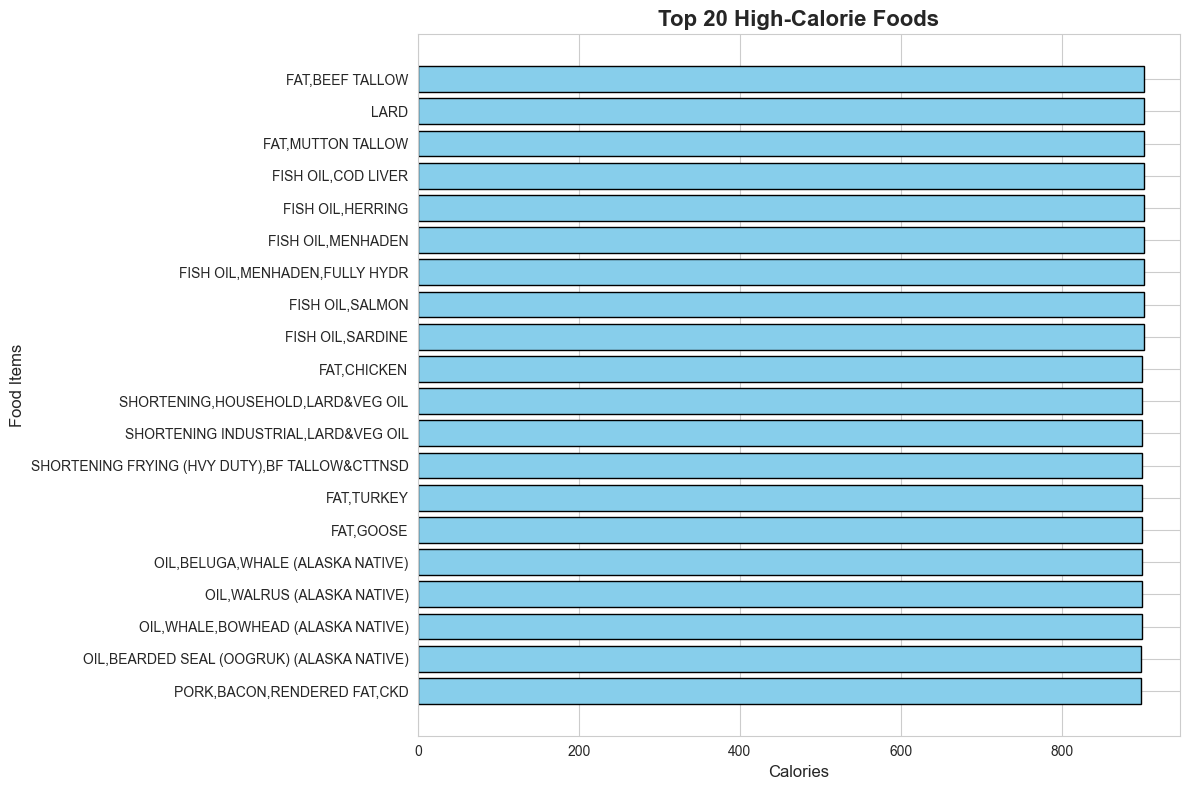


✅ Nutrition visualization saved!

Calorie Range: 0.0 - 902.0
Average Calories: 219.7
Median Calories: 181.0


In [11]:
# Cell 6: Visualize Nutrition Data (Top Foods by Calories)
try:
    # First, let's check what columns are actually in the dataset
    print("Available columns in nutrition dataset:")
    print(nutrition_df.columns.tolist())
    print("\n")
    
    # Check first few rows to understand structure
    print("First 3 rows:")
    print(nutrition_df.head(3))
    print("\n")
    
    # Try to identify calorie and name columns (they might have different names)
    calorie_col = None
    name_col = None
    
    # Check for calorie column variations
    for col in nutrition_df.columns:
        col_lower = col.lower()
        if 'calorie' in col_lower or 'energy' in col_lower or 'kcal' in col_lower:
            calorie_col = col
            print(f"✅ Found calorie column: {col}")
            break
    
    # Check for name column variations
    for col in nutrition_df.columns:
        col_lower = col.lower()
        if 'name' in col_lower or 'food' in col_lower or 'description' in col_lower or 'item' in col_lower:
            name_col = col
            print(f"✅ Found name column: {col}")
            break
    
    # If both columns found, create visualization
    if calorie_col and name_col:
        # Remove rows with missing values
        nutrition_clean = nutrition_df[[name_col, calorie_col]].dropna()
        
        # Convert calorie column to numeric if it's not
        nutrition_clean[calorie_col] = pd.to_numeric(nutrition_clean[calorie_col], errors='coerce')
        nutrition_clean = nutrition_clean.dropna()
        
        # Get top 20 foods by calories
        top_foods = nutrition_clean.nlargest(20, calorie_col)
        
        plt.figure(figsize=(12, 8))
        plt.barh(range(len(top_foods)), top_foods[calorie_col].values, color='skyblue', edgecolor='black')
        plt.yticks(range(len(top_foods)), top_foods[name_col].values)
        plt.xlabel('Calories', fontsize=12)
        plt.ylabel('Food Items', fontsize=12)
        plt.title('Top 20 High-Calorie Foods', fontsize=16, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig('../results/plots/nutrition_top_calories.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n✅ Nutrition visualization saved!")
        
        # Show some statistics
        print(f"\nCalorie Range: {nutrition_clean[calorie_col].min():.1f} - {nutrition_clean[calorie_col].max():.1f}")
        print(f"Average Calories: {nutrition_clean[calorie_col].mean():.1f}")
        print(f"Median Calories: {nutrition_clean[calorie_col].median():.1f}")
        
    else:
        print("⚠️ Could not automatically identify calorie or name columns")
        print("\nPlease manually specify columns:")
        print("Example: If columns are 'Food' and 'Energy_kcal', use:")
        print("name_col = 'Food'")
        print("calorie_col = 'Energy_kcal'")
        
        # Show column info to help identify
        print("\n--- Column Information ---")
        print(nutrition_df.info())
        
except Exception as e:
    print(f"⚠️ Error visualizing nutrition data: {e}")
    print("\nDebug information:")
    print(f"Error type: {type(e).__name__}")
    
    # Try simple alternative visualization
    try:
        print("\nAttempting simple visualization with numeric columns...")
        numeric_cols = nutrition_df.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            first_numeric = numeric_cols[0]
            plt.figure(figsize=(10, 6))
            plt.hist(nutrition_df[first_numeric].dropna(), bins=30, color='skyblue', edgecolor='black')
            plt.xlabel(first_numeric)
            plt.ylabel('Frequency')
            plt.title(f'Distribution of {first_numeric}')
            plt.tight_layout()
            plt.savefig('../results/plots/nutrition_distribution.png', dpi=300, bbox_inches='tight')
            plt.show()
            print("✅ Alternative visualization saved!")
    except:
        print("❌ Could not create alternative visualization")


In [7]:
# Cell 7: Load Exercise Dataset
try:
    exercise_df = pd.read_csv('../data/raw/exercise.csv')
    
    print("=" * 50)
    print("EXERCISE DATASET")
    print("=" * 50)
    print(f"\nShape: {exercise_df.shape}")
    print(f"Rows: {exercise_df.shape[0]}, Columns: {exercise_df.shape[1]}")
    
    print("\n--- Column Names ---")
    print(exercise_df.columns.tolist())
    
    print("\n--- First 10 Rows ---")
    print(exercise_df.head(10))
    
    print("\n--- Data Types ---")
    print(exercise_df.dtypes)
    
    print("\n--- Missing Values ---")
    print(exercise_df.isnull().sum())
    
    print("\n--- Statistical Summary ---")
    print(exercise_df.describe())
    
except FileNotFoundError:
    print("⚠️ Exercise dataset not found. Please download from Kaggle.")


EXERCISE DATASET

Shape: (248, 6)
Rows: 248, Columns: 6

--- Column Names ---
['Activity, Exercise or Sport (1 hour)', '130 lb', '155 lb', '180 lb', '205 lb', 'Calories per kg']

--- First 10 Rows ---
    Activity, Exercise or Sport (1 hour)  130 lb  155 lb  180 lb  205 lb  \
0            Cycling, mountain bike, bmx     502     598     695     791   
1    Cycling, <10 mph, leisure bicycling     236     281     327     372   
2               Cycling, >20 mph, racing     944    1126    1308    1489   
3            Cycling, 10-11.9 mph, light     354     422     490     558   
4         Cycling, 12-13.9 mph, moderate     472     563     654     745   
5         Cycling, 14-15.9 mph, vigorous     590     704     817     931   
6  Cycling, 16-19 mph, very fast, racing     708     844     981    1117   
7                             Unicycling     295     352     409     465   
8         Stationary cycling, very light     177     211     245     279   
9              Stationary cycling, ligh

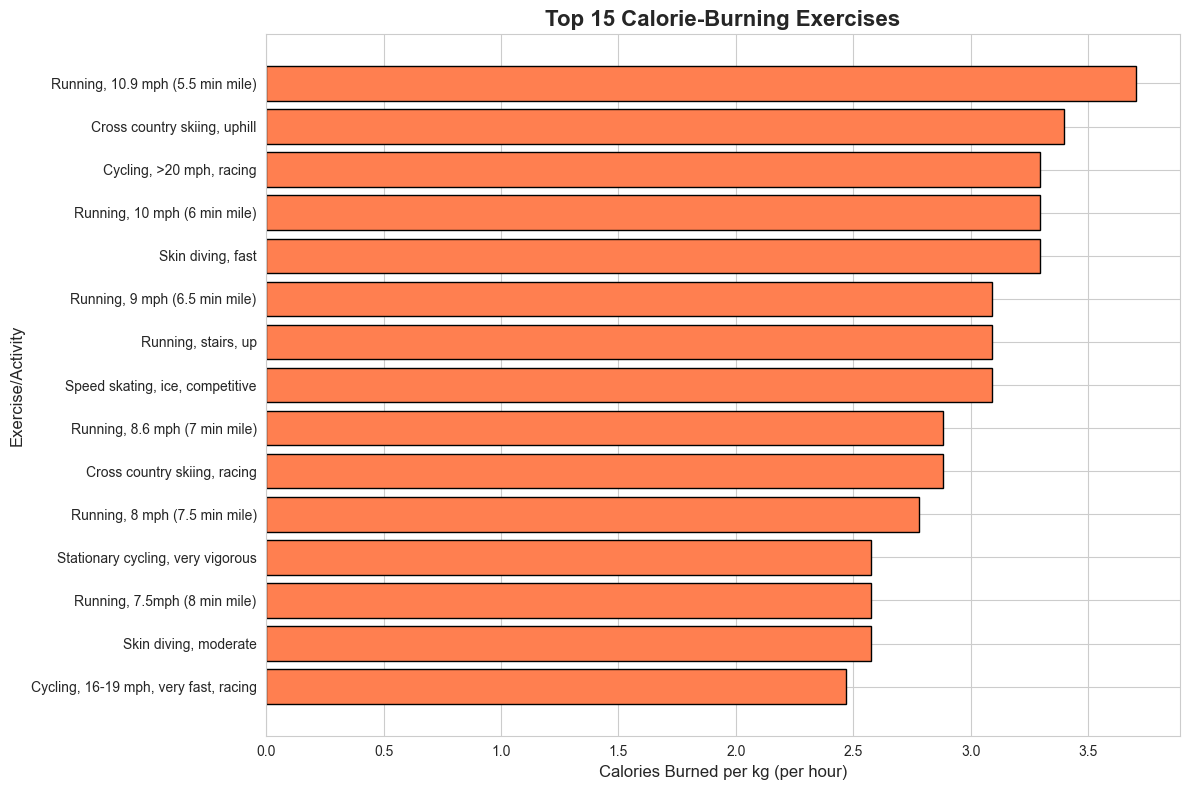

✅ Exercise visualization saved!


In [8]:
# Cell 8: Visualize Exercise Data
try:
    # Plot top 15 exercises by calories burned
    if 'Calories per kg' in exercise_df.columns and 'Activity, Exercise or Sport (1 hour)' in exercise_df.columns:
        top_exercises = exercise_df.nlargest(15, 'Calories per kg')
        
        plt.figure(figsize=(12, 8))
        plt.barh(top_exercises['Activity, Exercise or Sport (1 hour)'], 
                 top_exercises['Calories per kg'], 
                 color='coral', edgecolor='black')
        plt.xlabel('Calories Burned per kg (per hour)', fontsize=12)
        plt.ylabel('Exercise/Activity', fontsize=12)
        plt.title('Top 15 Calorie-Burning Exercises', fontsize=16, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig('../results/plots/exercise_top_calories.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("✅ Exercise visualization saved!")
    else:
        print("⚠️ Required columns not found in exercise dataset")
        
except Exception as e:
    print(f"⚠️ Error visualizing exercise data: {e}")


In [9]:
# Cell 9: Data Quality Summary
print("=" * 70)
print("DATA QUALITY SUMMARY")
print("=" * 70)

datasets = {
    'Diabetes': diabetes_df,
}

# Add nutrition and exercise if loaded
try:
    datasets['Nutrition'] = nutrition_df
except:
    pass

try:
    datasets['Exercise'] = exercise_df
except:
    pass

summary_data = []

for name, df in datasets.items():
    summary_data.append({
        'Dataset': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'Missing Values': df.isnull().sum().sum(),
        'Duplicates': df.duplicated().sum(),
        'Memory (MB)': round(df.memory_usage(deep=True).sum() / 1024**2, 2)
    })

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))

print("\n✅ Data exploration completed!")
print("\n📌 Next Steps:")
print("   1. Clean missing values")
print("   2. Handle outliers")
print("   3. Feature engineering")
print("   4. Save processed data")


DATA QUALITY SUMMARY

   Dataset  Rows  Columns  Missing Values  Duplicates  Memory (MB)
 Diabetes   768        9               0           0         0.05
Nutrition  7413       48            3570           0         4.49
 Exercise   248        6               0           0         0.03

✅ Data exploration completed!

📌 Next Steps:
   1. Clean missing values
   2. Handle outliers
   3. Feature engineering
   4. Save processed data


In [10]:
# Cell 10: Save Initial Insights
insights = {
    'total_datasets': len(datasets),
    'total_records': sum([df.shape[0] for df in datasets.values()]),
    'datasets_info': summary_df.to_dict('records')
}

# Save summary
summary_df.to_csv('../results/data_summary.csv', index=False)

print("✅ Summary saved to results/data_summary.csv")
print("\n" + "=" * 70)
print("PHASE 1 COMPLETE: DATA EXPLORATION")
print("=" * 70)


✅ Summary saved to results/data_summary.csv

PHASE 1 COMPLETE: DATA EXPLORATION
